# Modular Restaurant Choice Data Generation with Experimental Variations

<hr style="clear:both">

This notebook extends the basic restaurant choice model to include three key experimental factors that affect choice modeling difficulty and estimation performance:

- **I{0|1}**: Data imbalance (0 = balanced, 1 = imbalanced)
- **C{0|1}**: Correlation/clones (0 = independent, 1 = correlated)  
- **M{0|1}**: Choice randomness (0 = selective, 1 = random)

## Experimental Design Factors:

<!-- ### I - Data Imbalance
- **I=0**: Balanced attribute distributions and choice probabilities
- **I=1**: (i) Skewed attributes for first 10 alternatives, (ii) Japanese cuisine dominance (high β_Japanese)

### C - Correlation/Clones  
- **C=0**: Independent alternatives maintaining IIA property
- **C=1**: Near-duplicate alternatives to test IIA violations -->

### M - Choice Randomness
- **M=0**: Selective behavior (high utility scale = clear preferences)
- **M=1**: Random behavior (low utility scale = flat/uniform choices)

**Author:** [Anne-Valérie Preto](https://people.epfl.ch/anne-valerie.preto)

<hr style="clear:both">

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
from copy import deepcopy
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(8)
random.seed(8)


## Configuration Parameters

In [2]:
J = 100  # Number of restaurants, we should stick for now to 100,200,500
N = 10000  # Number of individuals, 10000, 20000, 50000
P = 50  # Number of parameters: 10 (base), 20 (+interactions), 50 (+extended features)

# Binary experimental factors
I = 0  # Data imbalance: 0 = balanced, 1 = imbalanced
C = 0  # Correlation/clones: 0 = independent, 1 = correlated
M = 0  # Choice randomness: 0 = selective, 1 = random

print(f"Configuration: J={J}, N={N}, P={P}")
print(f"Experimental factors: I={I}, C={C}, M={M}")
print(f"Dataset identifier: J{J}_P{P}_N{N//1000}k_I{I}C{C}M{M}")

Configuration: J=100, N=10000, P=50
Experimental factors: I=0, C=0, M=0
Dataset identifier: J100_P50_N10k_I0C0M0


## Base Data
The following functions create the base dataframe, with the attributes for the different parameters model.
 It will then be modified if we need data imbalance for example.

In [3]:
def generate_base_restaurants(J, P, rng_seed=42):
    """Generate base restaurant data before applying experimental variations"""
    
    # numpy random seed to match synthetic_data_generation.ipynb
    np.random.seed(rng_seed)
    
    # Cuisine types
    cuisines = ["Chinese", "Japanese", "Korean", "Indian", 
                "French", "Mexican", "Lebanese", "Ethiopian"]
    
    # Generate restaurant locations using the same method as synthetic_data_generation.ipynb
    def generate_locations(n):
        locations = []
        while len(locations) < n:
            x = np.random.uniform(0, 100)
            y = np.random.uniform(0, 100)
            locations.append((x, y))
        return np.array(locations)
    
    restaurant_locations = generate_locations(J)
    
    # Base attribute distributions
    rating = np.clip(np.random.normal(loc=4.2, scale=0.4, size=J), 1, 5)
    cost = np.clip(np.random.normal(loc=20, scale=5, size=J), 10, 35)
    
    # Assign cuisines
    cuisine_assignments = np.random.choice(cuisines, size=J)
    cuisine_dummies = pd.get_dummies(cuisine_assignments)
    
    # Ensure all cuisines are represented
    while cuisine_dummies.shape[1] < 8:
        cuisine_assignments = np.random.choice(cuisines, size=J)
        cuisine_dummies = pd.get_dummies(cuisine_assignments)
    
    # Additional features for P>=20 (using np.random instead of rng)
    additional_features = {}
    if P >= 20:
        # 5 unnamed continuous restaurant features for 20-param model (with varied distributions)
        additional_features['c_16'] = np.clip(np.random.normal(0, 1, size=J), -3, 3)
        additional_features['c_17'] = np.random.lognormal(mean=0, sigma=0.6, size=J)
        additional_features['c_18'] = np.clip(np.random.beta(2, 5, size=J), 0, 1)
        additional_features['c_19'] = np.clip(np.random.normal(3.0, 0.8, size=J), 1, 5)
        additional_features['c_20'] = np.clip(np.random.normal(0, 0.3, size=J), -1, 1)
    
    if P >= 50:
        # 15 unnamed continuous: c_21..c_35 (with varied distributions like in synthetic_data_restaurant)
        for k in range(21, 36):
            r = (k - 21) % 5
            if r == 0: additional_features[f'c_{k}'] = np.clip(np.random.normal(0, 1, size=J), -3, 3)       # N(0,1)
            if r == 1: additional_features[f'c_{k}'] = np.random.lognormal(mean=0, sigma=0.6, size=J)       # lognormal
            if r == 2: additional_features[f'c_{k}'] = np.clip(np.random.beta(2, 5, size=J), 0, 1)          # Beta(2,5)
            if r == 3: additional_features[f'c_{k}'] = np.clip(np.random.normal(3.0, 0.8, size=J), 1, 5)    # 1..5-ish
            if r == 4: additional_features[f'c_{k}'] = np.clip(np.random.normal(0, 0.3, size=J), -1, 1)     # small-scale

        # 15 unnamed discrete: d_36..d_50 (Bernoulli with varied probabilities)
        probs = [0.2,0.35,0.5,0.65,0.8, 0.25,0.4,0.6,0.7,0.3, 0.55,0.15,0.85,0.45,0.75]
        for k, p in zip(range(36, 51), probs):
            additional_features[f'd_{k}'] = np.random.binomial(1, p, size=J)
    
    # Build base DataFrame
    base_data = {
        "restaurant_id": np.arange(J),
        "x": restaurant_locations[:, 0],
        "y": restaurant_locations[:, 1], 
        "rating": rating,
        "cost": cost,
        "cuisine": cuisine_assignments,
        **additional_features #random, don't have real significations, but the scale of attributes change
    }
    
    df = pd.DataFrame(base_data).join(cuisine_dummies)
    return df, cuisine_assignments

def generate_base_individuals(N):
    """Generate base individual data"""
    
    
    # Generate individual locations using the same method as synthetic_data_generation.ipynb
    def generate_locations(n):
        locations = []
        while len(locations) < n:
            x = np.random.uniform(0, 100)
            y = np.random.uniform(0, 100)
            locations.append((x, y))
        return np.array(locations)
    
    individual_locations = generate_locations(N)
    
    # Individual characteristics (using old-style random generation)
    gender = np.random.binomial(1, 0.5, size=N)
    age = np.clip(np.random.normal(35, 12, size=N), 18, 80)
    education = np.random.choice(['base','secondary','tertiary'], size=N, p=[0.40,0.35,0.25])
    edu_secondary = (education=='secondary').astype(int)
    edu_tertiary = (education=='tertiary').astype(int)
    income_k = np.clip(np.random.lognormal(mean=np.log(60), sigma=0.5, size=N), 10, 250)
    logincome = np.log(income_k)
    risk = np.clip(np.random.normal(0.0, 1.0, size=N), -3, 3)
    
    df_individuals = pd.DataFrame({
        "individual_id": np.arange(N),
        "user_x": individual_locations[:, 0],
        "user_y": individual_locations[:, 1],
        "gender": gender,
        "age": age,
        "edu_secondary": edu_secondary,
        "edu_tertiary": edu_tertiary,
        "income_k": income_k,
        "logincome": logincome,
        "risk": risk
    })
    
    return df_individuals

def get_base_parameters(P):
    """Get base true parameters before applying experimental variations"""

    # Base 10 parameters (same as synthetic_data_generation.ipynb)
    base_params = {
        'beta_rating': 0.75,
        'beta_cost': -0.4,
        'beta_log_dist': -0.60,
        'beta_chinese': 0.75,
        'beta_japanese': 1.25,  # Will be modified by I factor -> but I'm not sure we should
        'beta_korean': 0.75,
        'beta_indian': 1,
        'beta_french': 0.75,
        'beta_mexican': 1.25,
        'beta_lebanese': 0.75,
    }
    
    if P >= 20:
        # Add interactions and continuous features (further reduced for balanced peakedness)
        base_params.update({
            'beta_cost_x_logincome': 0.02,    
            'beta_logdist_x_age': -0.02,       
            'beta_rating_x_risk': 0.03,       
            'beta_rating_x_edu_sec': 0.15,    
            'beta_rating_x_edu_tert': 0.1,   
            
            # 5 continuous restaurant features (further reduced)
            'beta_c_16': 0.03,                
            'beta_c_17': -0.01,                
            'beta_c_18': 0.02,                
            'beta_c_19': -0.01,                
            'beta_c_20': 0.04,                
        })
    
    if P >= 50:
        # 15 random continuous (mixed signs/magnitudes)
        base_params.update({
            'beta_c_21': 0.10, 'beta_c_22': -0.06, 'beta_c_23': 0.07,
            'beta_c_24': 0.12, 'beta_c_25': -0.04, 'beta_c_26': 0.05,
            'beta_c_27': 0.14, 'beta_c_28': -0.03, 'beta_c_29': 0.09,
            'beta_c_30': 0.11, 'beta_c_31': -0.02, 'beta_c_32': 0.06,
            'beta_c_33': 0.13, 'beta_c_34': -0.01, 'beta_c_35': 0.16,

            # 15 random discrete (Bernoulli features; mixed signs)
            'beta_d_36': 0.10, 'beta_d_37': 0.12, 'beta_d_38': -0.08,
            'beta_d_39': 0.06, 'beta_d_40': 0.09, 'beta_d_41': 0.11,
            'beta_d_42': -0.05, 'beta_d_43': 0.07, 'beta_d_44': 0.05,
            'beta_d_45': 0.13, 'beta_d_46': -0.06, 'beta_d_47': 0.04,
            'beta_d_48': -0.07, 'beta_d_49': 0.08, 'beta_d_50': 0.03,
        })
    
    return base_params


## Modular Variation Functions

Each experimental factor (I, C, M) is implemented as a modular function that can be applied independently.

In [4]:
# def apply_imbalance_factor(df_restaurants, parameters, I, rng_seed=42):
#     """
#     Apply data imbalance factor I
#     I=0: Balanced data (no changes)
#     I=1: (i) Heavy-tailed skewing for first 10 alternatives, (ii) Increase Japanese preference
#     """
#     df = df_restaurants.copy()
#     params = parameters.copy()
    
#     if I == 1:
#         rng = np.random.default_rng(rng_seed + 100)
        
#         # (i) Apply heavy-tailed distributions for luxury restaurant segment (first 10)
#         # Log-normal for locations (creates spatial clustering in high-value areas)
#         log_normal_x = rng.lognormal(mean=np.log(75), sigma=0.3, size=10)  # Cluster around x=75
#         log_normal_y = rng.lognormal(mean=np.log(75), sigma=0.3, size=10)  # Cluster around y=75
#         df.loc[0:9, 'x'] = np.clip(log_normal_x, 0, 100)  # Keep within bounds
#         df.loc[0:9, 'y'] = np.clip(log_normal_y, 0, 100)
        
#         # Pareto for cost (heavy tail towards expensive restaurants)
#         pareto_cost = rng.pareto(a=2.0, size=10) * 30 + 20  # Scale=30, shift to start at 20 CHF
#         df.loc[0:9, 'cost'] = np.clip(pareto_cost, 20, 50)  # Expensive restaurants
        
#         # Inverted Pareto for rating (heavy tail towards high ratings)
#         pareto_rating_raw = rng.pareto(a=3.0, size=10) * 1  # Scale=1
#         pareto_rating = 5.5 - pareto_rating_raw  # Invert: higher Pareto values become lower ratings
#         df.loc[0:9, 'rating'] = np.clip(pareto_rating, 4.2, 5.0)  # High-rated restaurants
        
#         # (ii) Increase Japanese cuisine preference significantly
#         # params['beta_japanese'] = 2.5  # Much higher than base 1.25 #maybe we shouldn't
        
#         print(f"Applied heavy-tailed imbalance (I=1):")
#         print(f"  - Log-normal locations: x∈[{df.loc[0:9, 'x'].min():.1f}, {df.loc[0:9, 'x'].max():.1f}], y∈[{df.loc[0:9, 'y'].min():.1f}, {df.loc[0:9, 'y'].max():.1f}]")
#         print(f"  - Pareto cost range: {df.loc[0:9, 'cost'].min():.1f}-{df.loc[0:9, 'cost'].max():.1f} CHF")
#         print(f"  - Inverted Pareto rating range: {df.loc[0:9, 'rating'].min():.2f}-{df.loc[0:9, 'rating'].max():.2f}")
#         # print(f"  - Japanese β parameter: {params['beta_japanese']:.2f}")
#     else:
#         print("No imbalance applied (I=0)")
    
#     return df, params

# def apply_correlation_factor(df_restaurants, C, rng_seed=42):
#     """
#     Apply correlation/clones factor C
#     C=0: Independent alternatives (no changes)
#     C=1: Create near-duplicate alternatives (clone groups)
#     """
#     df = df_restaurants.copy()
    
#     if C == 1:
#         rng = np.random.default_rng(rng_seed + 200)
        
#         # Create clone groups: every group of 5 restaurants will be similar
#         n_groups = min(20, len(df) // 5)  # Create up to 20 groups
        
#         for group in range(n_groups):
#             start_idx = group * 5
#             end_idx = min(start_idx + 5, len(df))
#             group_indices = list(range(start_idx, end_idx))
            
#             if len(group_indices) >= 2:
#                 # Pick the first restaurant as the "prototype"
#                 prototype_idx = group_indices[0]
                
#                 # Make others similar to the prototype (with small noise)
#                 for idx in group_indices[1:]:
#                     # Similar location (±5 units)
#                     df.loc[idx, 'x'] = df.loc[prototype_idx, 'x'] + rng.normal(0, 2)
#                     df.loc[idx, 'y'] = df.loc[prototype_idx, 'y'] + rng.normal(0, 2)
                    
#                     # Similar rating (±0.2 points)
#                     df.loc[idx, 'rating'] = np.clip(
#                         df.loc[prototype_idx, 'rating'] + rng.normal(0, 0.1), 1, 5
#                     )
                    
#                     # Similar cost (±2 CHF)
#                     df.loc[idx, 'cost'] = np.clip(
#                         df.loc[prototype_idx, 'cost'] + rng.normal(0, 1), 10, 45
#                     )
                    
#                     # Same cuisine
#                     df.loc[idx, 'cuisine'] = df.loc[prototype_idx, 'cuisine']
                    
#                     # Copy cuisine dummies
#                     cuisines = ["Chinese", "Japanese", "Korean", "Indian",
#                               "French", "Mexican", "Lebanese", "Ethiopian"]
#                     for cuisine in cuisines:
#                         if cuisine in df.columns:
#                             df.loc[idx, cuisine] = df.loc[prototype_idx, cuisine]
        
#         print(f"Applied correlation (C=1): Created {n_groups} clone groups")
#     else:
#         print("No correlation applied (C=0)")
    
#     return df

def get_scale(M):
    """
    Get utility scale parameter based on M factor (for multinomial logit)
    M=0: Selective behavior (scale = 2.0, clear preferences)
    M=1: Random behavior (scale = 0.2, flat/uniform choices)
    
    Higher scale = more selective (amplifies utility differences)
    Lower scale = more random (dampens utility differences)
    """
    if M == 1:
        scale = 0.1  # Random behavior = small scale = flat probabilities
        print(f"Applied rescaling (M=1): mu={scale}")
    else:
        scale = 1.0  # Selective behavior = large scale = clear preferences
        print("No rescaling applied (M=0)")
    
    return scale

# Modular variation functions defined

## Utility Computation and Choice Simulation

In [5]:
def compute_utility(user_x, user_y, user_data, df_restaurants, parameters, P):
    """
    Compute systematic utility for all restaurants for a given individual
    (Exactly matching the synthetic_data_generation.ipynb approach)
    """
    dists = np.sqrt((df_restaurants['x'] - user_x) ** 2 + (df_restaurants['y'] - user_y) ** 2)
    
    # Base utility (P=10) - matching the original exactly
    V = (
        parameters['beta_rating'] * df_restaurants["rating"].values +
        parameters['beta_cost'] * df_restaurants["cost"].values +
        parameters['beta_log_dist'] * np.log(dists) +
        sum(parameters[f'beta_{c.lower()}'] * df_restaurants[c].values 
            for c in ["Chinese", "Japanese", "Korean", "Indian", "French", "Mexican", "Lebanese"] 
            if c in df_restaurants.columns and f'beta_{c.lower()}' in parameters)
    )
    
    # Add interactions for P>=20
    if P >= 20:
        V += parameters['beta_cost_x_logincome'] * (df_restaurants["cost"].values * user_data['logincome'])
        V += parameters['beta_logdist_x_age'] * (np.log(dists) * user_data['age'])
        V += parameters['beta_rating_x_risk'] * (df_restaurants["rating"].values * user_data['risk'])
        V += parameters['beta_rating_x_edu_sec'] * (df_restaurants["rating"].values * user_data['edu_secondary'])
        V += parameters['beta_rating_x_edu_tert'] * (df_restaurants["rating"].values * user_data['edu_tertiary'])
        
        # Additional features
        for i in range(16, 21):
            feat = f'c_{i}'
            if feat in df_restaurants.columns and f'beta_{feat}' in parameters:
                V += parameters[f'beta_{feat}'] * df_restaurants[feat].values
    
    if P >= 50:
        # More features
        for i in range(21, 36):
            feat = f'c_{i}'
            if feat in df_restaurants.columns and f'beta_{feat}' in parameters:
                V += parameters[f'beta_{feat}'] * df_restaurants[feat].values
        
        for i in range(36, 51):
            feat = f'd_{i}'
            if feat in df_restaurants.columns and f'beta_{feat}' in parameters:
                V += parameters[f'beta_{feat}'] * df_restaurants[feat].values
    
    return V

def simulate_choices(df_individuals, df_restaurants, parameters, P, noise_scale=1.0, rng_seed=None, return_probs=False):
    """
    Simulate choice for all individuals using modular utility formulas based on P parameter
    Includes minimum distance threshold to prevent log(0) = -inf
    
    Parameters:
    -----------
    df_individuals : DataFrame
        Individual data with locations and characteristics
    df_restaurants : DataFrame  
        Restaurant data with attributes and locations
    parameters : dict
        Model parameters (beta coefficients)
    noise_scale : float, default 1.0
        Utility scaling factor (higher = more deterministic, lower = more random)
    rng_seed : int, optional
        Random seed for reproducibility
    return_probs : bool, default False
        If True, returns (df_choices, choice_probabilities)
        If False, returns only df_choices for backward compatibility
    
    Returns:
    --------
    df_choices : DataFrame
        Individual choices with columns [individual_id, restaurant_id, cuisine]
    choice_probabilities : list of arrays (only if return_probs=True)
        List of probability arrays, one per individual (length N)
        Each array has length J with probabilities for each restaurant
    """
    choices = []
    all_probabilities = [] if return_probs else None
    
    for i in range(len(df_individuals)):
        user_x = df_individuals.loc[i, 'user_x']
        user_y = df_individuals.loc[i, 'user_y']
        user_data = df_individuals.loc[i]  # Get full individual data for interactions
        
        # Compute utility using the centralized function
        V = compute_utility(user_x, user_y, user_data, df_restaurants, parameters, P)

        # Utility scaling to control choice randomness/flatness
        # Higher scale = more deterministic, Lower scale = more random/flat
        V = V * noise_scale

        # Compute choice probabilities using softmax
        V = V - np.max(V)  # for numerical stability
        exp_V = np.exp(V)
        probs = exp_V / exp_V.sum()
        
        # Store probabilities if requested
        if return_probs:
            all_probabilities.append(probs.copy())

        # Draw one alternative according to logit probabilities
        chosen_idx = np.random.choice(len(df_restaurants), p=probs)
        choices.append((i, df_restaurants.loc[chosen_idx, "restaurant_id"]))
    
    df_choices = pd.DataFrame(choices, columns=["individual_id", "restaurant_id"])
    
    # Add chosen restaurant info
    df_choices["cuisine"] = df_choices["restaurant_id"].map(
        df_restaurants.set_index("restaurant_id")["cuisine"]
    )
    
    if return_probs:
        return df_choices, all_probabilities
    else:
        return df_choices

def analyze_choice_probabilities(choice_probabilities, df_restaurants, sample_size=100):
    """
    Analyze the choice probability distributions to assess model signal strength
    
    Parameters:
    -----------
    choice_probabilities : list of arrays
        Probability arrays from simulate_choices with return_probs=True
    df_restaurants : DataFrame
        Restaurant data for context
    sample_size : int
        Number of individuals to analyze (for performance)
    
    Returns:
    --------
    dict : Analysis results including entropy, max prob, effective choice set size
    """
    # Sample individuals for analysis
    n_individuals = len(choice_probabilities)
    sample_indices = np.random.choice(n_individuals, min(sample_size, n_individuals), replace=False)
    
    # Calculate metrics for each individual
    entropies = []
    max_probs = []
    effective_sizes = []
    gini_coeffs = []
    
    for idx in sample_indices:
        probs = choice_probabilities[idx]
        
        # Shannon entropy (higher = more uniform)
        entropy = -np.sum(probs * np.log(probs + 1e-10))  # Add small constant to avoid log(0)
        entropies.append(entropy)
        
        # Maximum probability (higher = more peaked)
        max_prob = np.max(probs)
        max_probs.append(max_prob)
        
        # Effective choice set size (number of alternatives with non-negligible probability)
        effective_size = np.sum(probs > 0.01)  # Count alternatives with >1% probability
        effective_sizes.append(effective_size)
        
        # Gini coefficient (0 = uniform, 1 = concentrated)
        sorted_probs = np.sort(probs)
        n = len(sorted_probs)
        gini = (2 * np.sum((np.arange(1, n+1) * sorted_probs))) / (n * np.sum(sorted_probs)) - (n+1)/n
        gini_coeffs.append(gini)
    
    # Calculate summary statistics
    max_possible_entropy = np.log(len(df_restaurants))
    
    return {
        'shannon_entropy': {
            'mean': np.mean(entropies),
            'std': np.std(entropies),
            'min': np.min(entropies),
            'max': np.max(entropies),
            'max_possible': max_possible_entropy
        },
        'max_probability': {
            'mean': np.mean(max_probs),
            'std': np.std(max_probs),
            'min': np.min(max_probs),
            'max': np.max(max_probs)
        },
        'effective_choice_set': {
            'mean': np.mean(effective_sizes),
            'std': np.std(effective_sizes),
            'min': np.min(effective_sizes),
            'max': np.max(effective_sizes),
            'total_alternatives': len(df_restaurants)
        },
        'gini_coefficient': {
            'mean': np.mean(gini_coeffs),
            'std': np.std(gini_coeffs),
            'min': np.min(gini_coeffs),
            'max': np.max(gini_coeffs)
        }
    }

## Generate Dataset with Current Configuration

Apply the experimental factors and generate the complete dataset:

In [6]:
# Generate base data
print(f"Generating dataset: J{J}_P{P}_N{N//1000}k_I{I}C{C}M{M}")

# Step 1: Generate base restaurants and individuals
df_restaurants_base, cuisine_assignments = generate_base_restaurants(J, P, rng_seed=8)
df_individuals = generate_base_individuals(N)
base_parameters = get_base_parameters(P)

print(f"✓ {J} restaurants, {N} individuals, {len(base_parameters)} parameters")

# Step 2: Apply experimental factors
# df_restaurants, parameters = apply_imbalance_factor(df_restaurants_base, base_parameters, I)
df_restaurants, parameters = df_restaurants_base, base_parameters
# df_restaurants = apply_correlation_factor(df_restaurants, C)
scaling_factor = get_scale(M)

Generating dataset: J100_P50_N10k_I0C0M0
✓ 100 restaurants, 10000 individuals, 50 parameters
No rescaling applied (M=0)


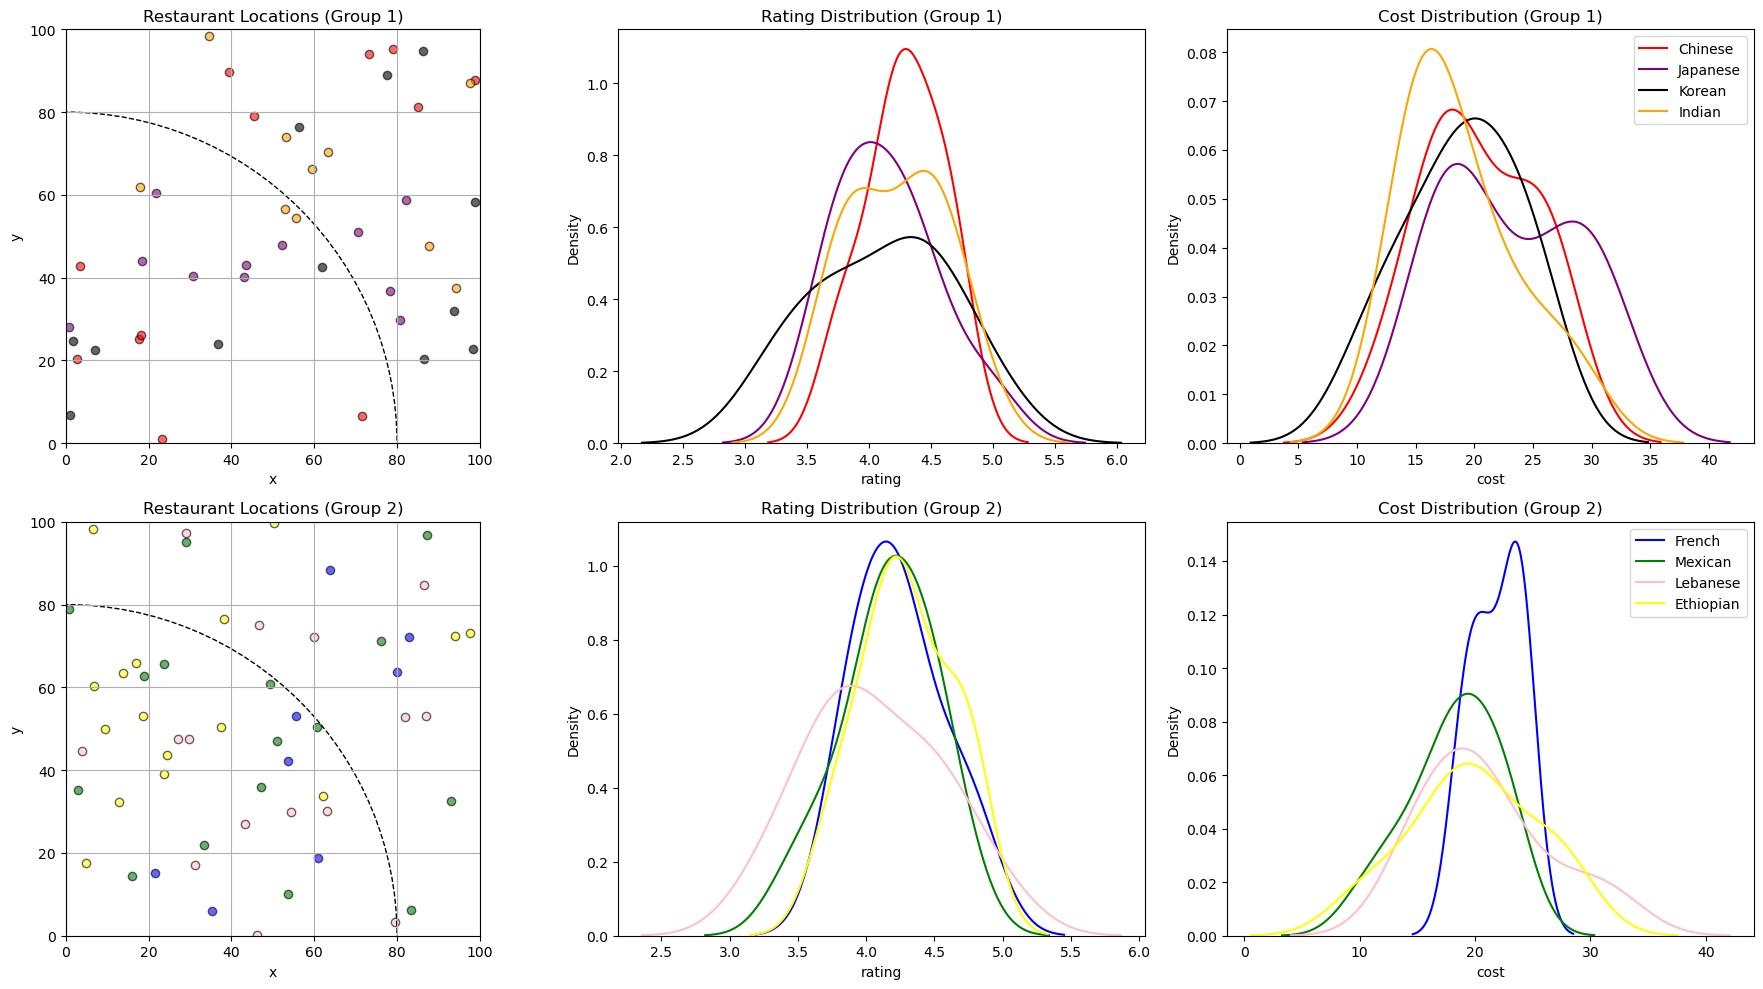

In [7]:
# Define cuisine groups and colors
group1 = ["Chinese", "Japanese", "Korean", "Indian"]
group2 = ["French", "Mexican", "Lebanese", "Ethiopian"]
cuisine_colors = {
    "Chinese": "red",
    "Japanese": "purple",
    "Korean": "black",
    "Indian": "orange",
    "French": "blue",
    "Mexican": "green",
    "Lebanese": "pink",
    "Ethiopian": "yellow"
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=False, sharey=False)

# Plot 1: Restaurant map (group1)
ax = axes[0, 0]
for cuisine in group1:
    subset = df_restaurants[df_restaurants["cuisine"] == cuisine]
    ax.scatter(subset["x"], subset["y"], alpha=0.6, label=cuisine, color=cuisine_colors[cuisine], edgecolor="black")
circle = plt.Circle((0, 0), 80, color='black', fill=False, linestyle='--')
ax.add_artist(circle)
ax.set_title("Restaurant Locations (Group 1)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.set_aspect('equal', adjustable='box')
ax.grid(True)

# Plot 2: Rating (group1)
ax = axes[0, 1]
for cuisine in group1:
    sns.kdeplot(df_restaurants[df_restaurants["cuisine"] == cuisine]["rating"], ax=ax, label=cuisine, color=cuisine_colors[cuisine])
ax.set_title("Rating Distribution (Group 1)")

# Plot 3: Cost (group1)
ax = axes[0, 2]
for cuisine in group1:
    sns.kdeplot(df_restaurants[df_restaurants["cuisine"] == cuisine]["cost"], ax=ax, label=cuisine, color=cuisine_colors[cuisine])
ax.set_title("Cost Distribution (Group 1)")
ax.legend()

# Plot 4: Restaurant map (group2)
ax = axes[1, 0]
for cuisine in group2:
    subset = df_restaurants[df_restaurants["cuisine"] == cuisine]
    ax.scatter(subset["x"], subset["y"], alpha=0.6, label=cuisine, color=cuisine_colors[cuisine], edgecolor="black")
circle = plt.Circle((0, 0), 80, color='black', fill=False, linestyle='--')
ax.add_artist(circle)
ax.set_title("Restaurant Locations (Group 2)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.set_aspect('equal', adjustable='box')
ax.grid(True)


# Plot 5: Rating (group2)
ax = axes[1, 1]
for cuisine in group2:
    sns.kdeplot(df_restaurants[df_restaurants["cuisine"] == cuisine]["rating"], ax=ax, label=cuisine, color=cuisine_colors[cuisine])
ax.set_title("Rating Distribution (Group 2)")


# Plot 6: Cost (group2)
ax = axes[1, 2]
for cuisine in group2:
    sns.kdeplot(df_restaurants[df_restaurants["cuisine"] == cuisine]["cost"], ax=ax, label=cuisine, color=cuisine_colors[cuisine])
ax.set_title("Cost Distribution (Group 2)")
ax.legend()

plt.tight_layout()
plt.show()


Text(0, 0.5, 'Frequency')

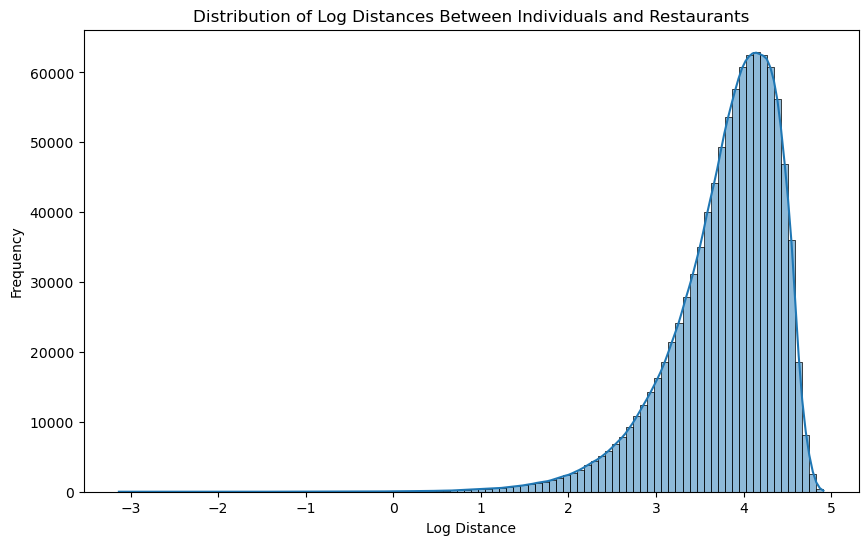

In [8]:
# plot distribution of log_distances between individuals and restaurants
distances = np.sqrt((df_restaurants['x'].values - df_individuals['user_x'].values[:, None]) ** 2 + 
                    (df_restaurants['y'].values - df_individuals['user_y'].values[:, None]) ** 2)
log_distances = np.log(distances)
plt.figure(figsize=(10, 6))
sns.histplot(log_distances.flatten(), bins=100, kde=True)
plt.title("Distribution of Log Distances Between Individuals and Restaurants")
plt.xlabel("Log Distance")
plt.ylabel("Frequency") 

In [9]:
print(f"\n✓ Final parameters: {len(parameters)} parameters")

# Step 3: Simulate choices WITH probability storage
print(f"\nSimulating choices with noise scale = {scaling_factor}")
df_choices, choice_probabilities = simulate_choices(
    df_individuals, df_restaurants, parameters, P, scaling_factor, return_probs=True
)

print(f"✓ Generated {len(df_choices)} choices")
print(f"✓ Stored {len(choice_probabilities)} probability distributions")
print(f"✓ Each probability array has {len(choice_probabilities[0])} elements (one per restaurant)")
print("="*60)


✓ Final parameters: 50 parameters

Simulating choices with noise scale = 1.0
✓ Generated 10000 choices
✓ Stored 10000 probability distributions
✓ Each probability array has 100 elements (one per restaurant)


## Dataset Analysis and Validation

In [10]:
# Analyze choice patterns
choice_counts = df_choices["restaurant_id"].value_counts().sort_index()
df_restaurants["times_chosen"] = df_restaurants["restaurant_id"].map(choice_counts).fillna(0).astype(int)

# Cuisine choice distribution
cuisine_choice_counts = df_choices["cuisine"].value_counts().sort_values(ascending=False)

print("Choice Analysis:")

print("Cuisine distribution:")
for cuisine, count in cuisine_choice_counts.items():
    percentage = (count / len(df_choices)) * 100
    print(f"  {cuisine:12s}: {count:5d} ({percentage:4.1f}%)")

print(f"Restaurants: max={df_restaurants['times_chosen'].max()}, min={df_restaurants['times_chosen'].min()}, never_chosen={(df_restaurants['times_chosen'] == 0).sum()}, avg={df_restaurants['times_chosen'].mean():.1f}")

# Experimental factor validation
if I == 1:
    japanese_share = cuisine_choice_counts.get('Japanese', 0) / len(df_choices)
    print(f"I=1 validation: Japanese share={japanese_share:.1%}, β_Japanese={parameters['beta_japanese']:.2f}")

if C == 1:
    group_0_costs = df_restaurants.loc[0:4, 'cost'].values
    print(f"C=1 validation: clone groups created, cost std={np.std(group_0_costs):.2f}")

print(f"M={M} validation: noise_scale={scaling_factor}")

Choice Analysis:
Cuisine distribution:
  Mexican     :  2867 (28.7%)
  Indian      :  1375 (13.8%)
  Ethiopian   :  1284 (12.8%)
  Chinese     :  1191 (11.9%)
  Korean      :  1096 (11.0%)
  Lebanese    :  1068 (10.7%)
  Japanese    :   933 ( 9.3%)
  French      :   186 ( 1.9%)
Restaurants: max=927, min=0, never_chosen=2, avg=100.0
M=0 validation: noise_scale=1.0


In [11]:
# Analyze choice probability distributions to assess model signal strength
print("PROBABILITY DISTRIBUTION ANALYSIS")
print("="*50)

# Analyze a sample of probability distributions
prob_analysis = analyze_choice_probabilities(choice_probabilities, df_restaurants, sample_size=1000)

print("Shannon Entropy (Higher = More Uniform Choice):")
entropy = prob_analysis['shannon_entropy']
print(f"  Mean: {entropy['mean']:.3f} ± {entropy['std']:.3f}")
print(f"  Range: [{entropy['min']:.3f}, {entropy['max']:.3f}]")
print(f"  Max possible (uniform): {entropy['max_possible']:.3f}")
print(f"  Uniformity ratio: {entropy['mean']/entropy['max_possible']:.1%}")

print("\n Maximum Probability (Higher = More Peaked):")
max_prob = prob_analysis['max_probability']
print(f"  Mean: {max_prob['mean']:.3f} ± {max_prob['std']:.3f}")
print(f"  Range: [{max_prob['min']:.3f}, {max_prob['max']:.3f}]")
print(f"  Expected for uniform: {1/len(df_restaurants):.3f}")

print("\n Effective Choice Set Size (Alternatives with >1% probability):")
eff_size = prob_analysis['effective_choice_set']
print(f"  Mean: {eff_size['mean']:.1f} (range: {eff_size['min']:.0f}-{eff_size['max']:.0f})")
print(f"  Coverage: {eff_size['mean']/eff_size['total_alternatives']:.1%} of {eff_size['total_alternatives']} alternatives")

print("\n Gini Coefficient (0=Uniform, 1=Concentrated):")
gini = prob_analysis['gini_coefficient']
print(f"  Mean: {gini['mean']:.3f} ± {gini['std']:.3f}")

# Signal assessment
print(f"\n Model Assessment: ", end="")
entropy_ratio = entropy['mean']/entropy['max_possible']
if entropy_ratio > 0.8:
    print("Strong signal ✅")
elif entropy_ratio > 0.6:
    print("Moderate signal ⚠️")
else:
    print("Weak signal ❌")

if max_prob['mean'] > 0.3:
    signal_strength = "Clear preferences ✅"
elif max_prob['mean'] > 0.15:
    signal_strength = "Moderate preferences ⚠️"
else:
    signal_strength = "Weak preferences ❌"
print(f"    {signal_strength}")

print(f"\n Key thresholds: Entropy <3.0=peaked, Max prob >0.5=strong, Eff.size <20=good discrimination")

PROBABILITY DISTRIBUTION ANALYSIS
Shannon Entropy (Higher = More Uniform Choice):
  Mean: 3.239 ± 0.547
  Range: [0.069, 3.796]
  Max possible (uniform): 4.605
  Uniformity ratio: 70.3%

 Maximum Probability (Higher = More Peaked):
  Mean: 0.234 ± 0.154
  Range: [0.074, 0.993]
  Expected for uniform: 0.010

 Effective Choice Set Size (Alternatives with >1% probability):
  Mean: 21.2 (range: 1-30)
  Coverage: 21.2% of 100 alternatives

 Gini Coefficient (0=Uniform, 1=Concentrated):
  Mean: 0.760 ± 0.061

 Model Assessment: Moderate signal ⚠️
    Moderate preferences ⚠️

 Key thresholds: Entropy <3.0=peaked, Max prob >0.5=strong, Eff.size <20=good discrimination


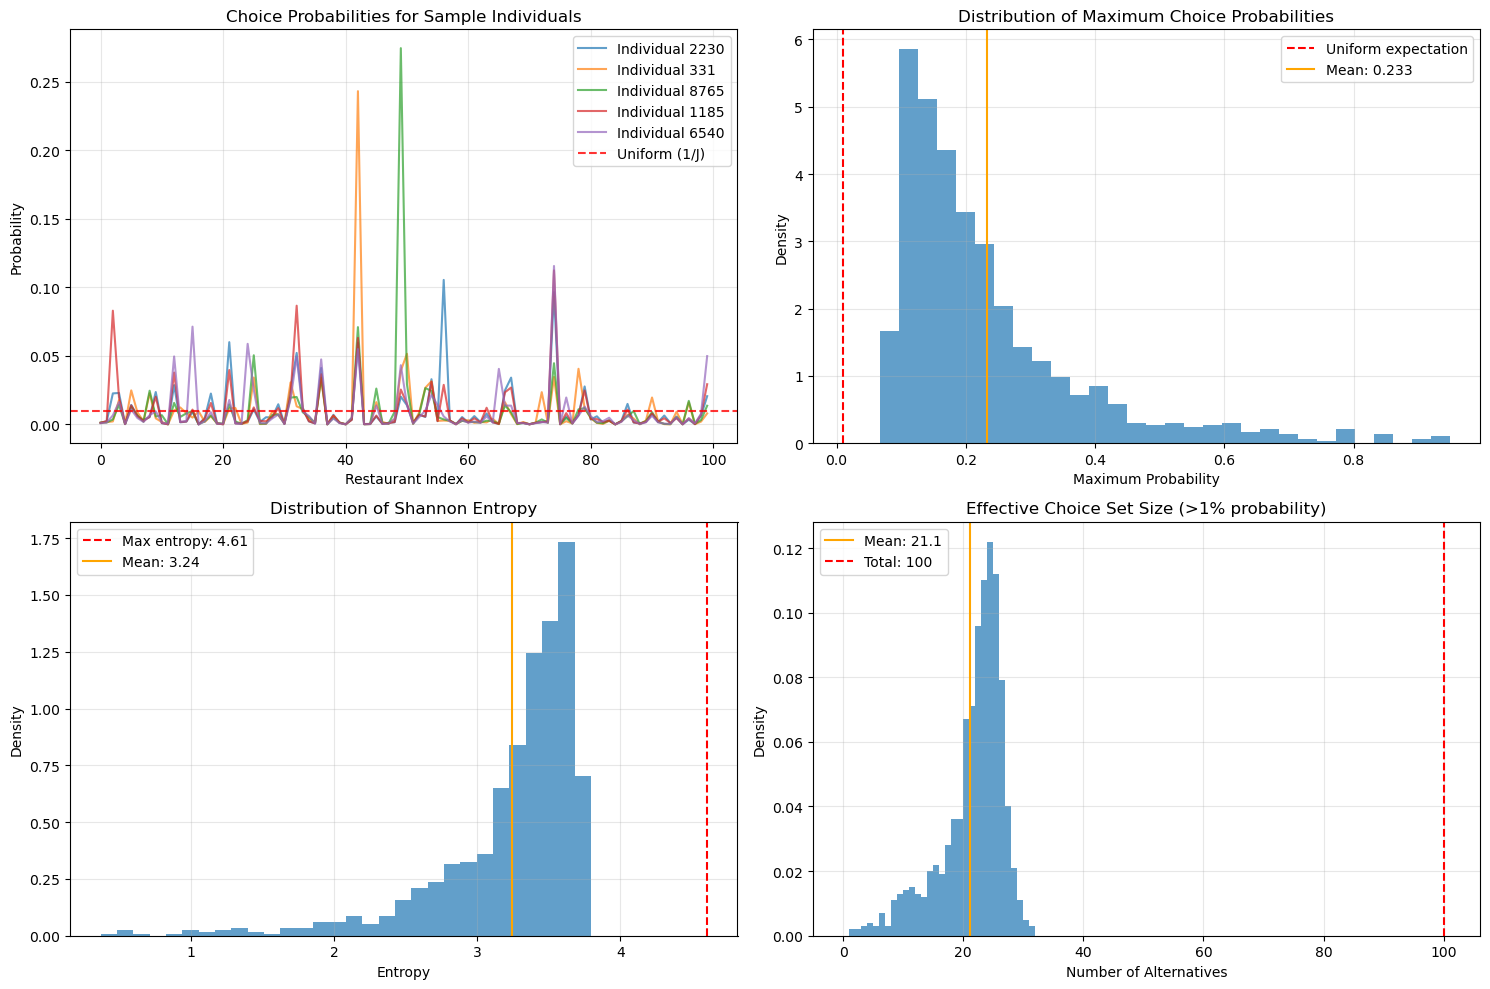

In [12]:
# Visualize probability distributions
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Sample a few individuals for visualization
sample_individuals = np.random.choice(len(choice_probabilities), 5, replace=False)

# Plot 1: Probability distributions for sample individuals
ax = axes[0, 0]
for i, ind_idx in enumerate(sample_individuals):
    probs = choice_probabilities[ind_idx]
    ax.plot(probs, alpha=0.7, label=f'Individual {ind_idx}')
ax.axhline(y=1/len(df_restaurants), color='red', linestyle='--', alpha=0.8, label='Uniform (1/J)')
ax.set_title('Choice Probabilities for Sample Individuals')
ax.set_xlabel('Restaurant Index')
ax.set_ylabel('Probability')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Distribution of maximum probabilities
ax = axes[0, 1]
max_probs = [np.max(probs) for probs in choice_probabilities[:1000]]  # Sample for performance
ax.hist(max_probs, bins=30, alpha=0.7, density=True)
ax.axvline(x=1/len(df_restaurants), color='red', linestyle='--', label='Uniform expectation')
ax.axvline(x=np.mean(max_probs), color='orange', linestyle='-', label=f'Mean: {np.mean(max_probs):.3f}')
ax.set_title('Distribution of Maximum Choice Probabilities')
ax.set_xlabel('Maximum Probability')
ax.set_ylabel('Density')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Shannon entropy distribution
ax = axes[1, 0]
entropies = [-np.sum(probs * np.log(probs + 1e-10)) for probs in choice_probabilities[:1000]]
ax.hist(entropies, bins=30, alpha=0.7, density=True)
max_entropy = np.log(len(df_restaurants))
ax.axvline(x=max_entropy, color='red', linestyle='--', label=f'Max entropy: {max_entropy:.2f}')
ax.axvline(x=np.mean(entropies), color='orange', linestyle='-', label=f'Mean: {np.mean(entropies):.2f}')
ax.set_title('Distribution of Shannon Entropy')
ax.set_xlabel('Entropy')
ax.set_ylabel('Density')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: Effective choice set size
ax = axes[1, 1]
eff_sizes = [np.sum(probs > 0.01) for probs in choice_probabilities[:1000]]
ax.hist(eff_sizes, bins=range(0, len(df_restaurants)+2), alpha=0.7, density=True)
ax.axvline(x=np.mean(eff_sizes), color='orange', linestyle='-', label=f'Mean: {np.mean(eff_sizes):.1f}')
ax.axvline(x=len(df_restaurants), color='red', linestyle='--', label=f'Total: {len(df_restaurants)}')
ax.set_title('Effective Choice Set Size (>1% probability)')
ax.set_xlabel('Number of Alternatives')
ax.set_ylabel('Density')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Noise level comparison: M=0 vs M=1

 COMPARISON RESULTS:
M=0 (Deterministic, scale=1.0):
  Shannon Entropy: 2.243 (48.7% of maximum)
  Max Probability: 0.410
  Effective Choice Set: 13

M=1 (Random/Flat, scale=0.1):
  Shannon Entropy: 4.532 (98.4% of maximum)
  Max Probability: 0.021
  Effective Choice Set: 44

 DIFFERENCE:
  Entropy increase: 2.289 (102.0%)
  Max prob decrease: 0.389
  More alternatives considered: +31


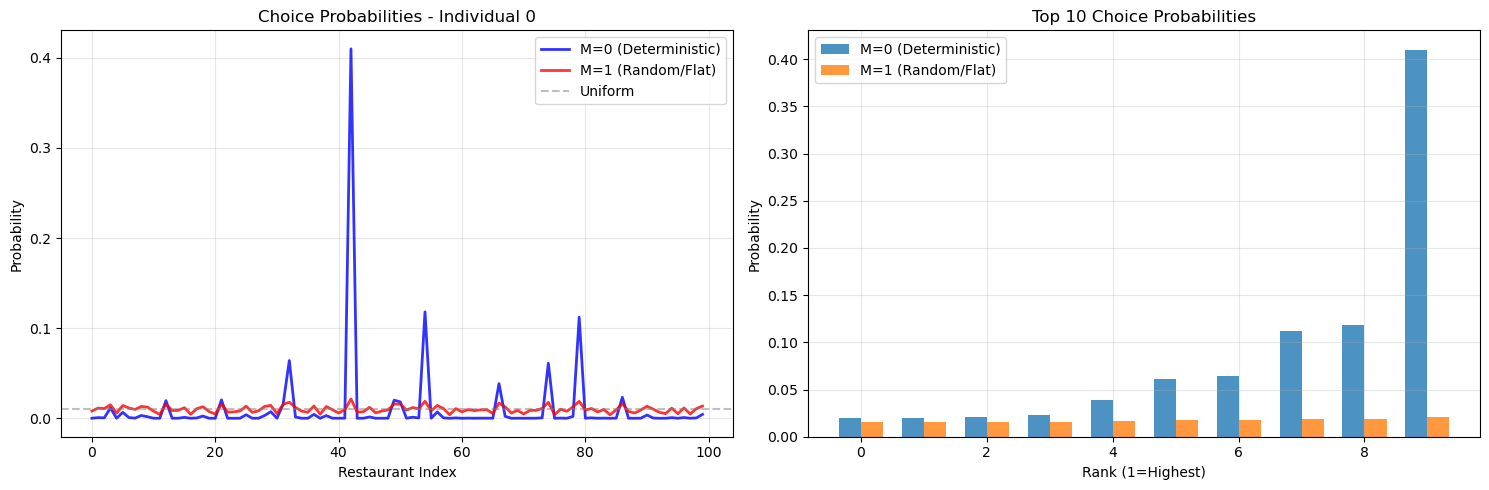


 Noise scaling is working correctly!
   M=0 → Deterministic choices (high utility scale)
   M=1 → Random/flat choices (low utility scale)


In [13]:
# Demonstrate the effect of different noise levels (M parameter)
print("Noise level comparison: M=0 vs M=1")

# Test with both noise levels using same data
sample_individual = 0
user_x = df_individuals.loc[sample_individual, 'user_x'] 
user_y = df_individuals.loc[sample_individual, 'user_y']

# Compute base utility
dists = np.sqrt((df_restaurants['x'] - user_x) ** 2 + (df_restaurants['y'] - user_y) ** 2)
dists = np.maximum(dists, 1e-10)

V_base = (
    parameters['beta_rating'] * df_restaurants["rating"].values +
    parameters['beta_cost'] * df_restaurants["cost"].values +
    parameters['beta_log_dist'] * np.log(dists) +
    sum(parameters[f'beta_{c.lower()}'] * df_restaurants[c].values 
        for c in ["Chinese", "Japanese", "Korean", "Indian", "French", "Mexican", "Lebanese"] 
        if c in df_restaurants.columns and f'beta_{c.lower()}' in parameters)
)

# Test M=0 (deterministic)
scale_M0 = 2.0  # Low noise
V_M0 = V_base * scale_M0
V_M0 = V_M0 - np.max(V_M0)
probs_M0 = np.exp(V_M0) / np.sum(np.exp(V_M0))

# Test M=1 (random/flat)  
scale_M1 = 0.2  # High noise
V_M1 = V_base * scale_M1
V_M1 = V_M1 - np.max(V_M1)
probs_M1 = np.exp(V_M1) / np.sum(np.exp(V_M1))

# Analyze differences
entropy_M0 = -np.sum(probs_M0 * np.log(probs_M0 + 1e-10))
entropy_M1 = -np.sum(probs_M1 * np.log(probs_M1 + 1e-10))
max_entropy = np.log(len(df_restaurants))

print(f"\n COMPARISON RESULTS:")
print(f"M=0 (Deterministic, scale=1.0):")
print(f"  Shannon Entropy: {entropy_M0:.3f} ({entropy_M0/max_entropy:.1%} of maximum)")
print(f"  Max Probability: {np.max(probs_M0):.3f}")
print(f"  Effective Choice Set: {np.sum(probs_M0 > 0.01)}")

print(f"\nM=1 (Random/Flat, scale=0.1):")
print(f"  Shannon Entropy: {entropy_M1:.3f} ({entropy_M1/max_entropy:.1%} of maximum)")
print(f"  Max Probability: {np.max(probs_M1):.3f}")
print(f"  Effective Choice Set: {np.sum(probs_M1 > 0.01)}")

print(f"\n DIFFERENCE:")
print(f"  Entropy increase: {entropy_M1 - entropy_M0:.3f} ({(entropy_M1/entropy_M0 - 1)*100:.1f}%)")
print(f"  Max prob decrease: {np.max(probs_M0) - np.max(probs_M1):.3f}")
print(f"  More alternatives considered: +{np.sum(probs_M1 > 0.01) - np.sum(probs_M0 > 0.01)}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot probability distributions
axes[0].plot(probs_M0, 'b-', alpha=0.8, linewidth=2, label='M=0 (Deterministic)')
axes[0].plot(probs_M1, 'r-', alpha=0.8, linewidth=2, label='M=1 (Random/Flat)')
axes[0].axhline(y=1/len(df_restaurants), color='gray', linestyle='--', alpha=0.5, label='Uniform')
axes[0].set_title(f'Choice Probabilities - Individual {sample_individual}')
axes[0].set_xlabel('Restaurant Index')
axes[0].set_ylabel('Probability')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot top 10 probabilities
top_10_M0 = np.sort(probs_M0)[-10:]
top_10_M1 = np.sort(probs_M1)[-10:]
x = np.arange(10)
width = 0.35

axes[1].bar(x - width/2, top_10_M0, width, label='M=0 (Deterministic)', alpha=0.8)
axes[1].bar(x + width/2, top_10_M1, width, label='M=1 (Random/Flat)', alpha=0.8)
axes[1].set_title('Top 10 Choice Probabilities')
axes[1].set_xlabel('Rank (1=Highest)')
axes[1].set_ylabel('Probability')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n Noise scaling is working correctly!")
print("   M=0 → Deterministic choices (high utility scale)")
print("   M=1 → Random/flat choices (low utility scale)")
print("="*60)

In [14]:
# DEMONSTRATION: Why Cell 18 looks good even with M=1
print("="*70)
print("🔍 EXPLAINING THE APPARENT CONTRADICTION: Cell 18 vs Cell 20")
print("="*70)

print("\n📊 CURRENT ANALYSIS (Cell 18 style): Population-level with M=1")
print("-" * 50)

# Show what Cell 18 is actually measuring
current_prob_analysis = analyze_choice_probabilities(choice_probabilities, df_restaurants, sample_size=1000)
entropy_mean = current_prob_analysis['shannon_entropy']['mean']
entropy_max = current_prob_analysis['shannon_entropy']['max_possible']
max_prob_mean = current_prob_analysis['max_probability']['mean']

print(f"Population entropy (M=1): {entropy_mean:.3f} ({entropy_mean/entropy_max:.1%} of maximum)")
print(f"Average max probability: {max_prob_mean:.3f}")
print(f"→ This looks 'reasonable' because it's averaged across 10,000 people!")

print(f"\n🧐 BUT LET'S LOOK AT INDIVIDUAL LEVEL (Cell 20 style):")
print("-" * 50)

# Sample 5 individuals and show their individual entropy
sample_individuals = [0, 100, 500, 1000, 2000]
individual_entropies_M1 = []

for i in sample_individuals:
    probs = choice_probabilities[i]
    entropy_individual = -np.sum(probs * np.log(probs + 1e-10))
    individual_entropies_M1.append(entropy_individual)
    flatness = entropy_individual / entropy_max
    print(f"Individual {i}: entropy = {entropy_individual:.3f} ({flatness:.1%} flat)")

print(f"\n🎯 COMPARISON WITH UNIFORM DISTRIBUTION:")
uniform_entropy = np.log(len(df_restaurants))
print(f"Perfectly uniform entropy: {uniform_entropy:.3f}")
print(f"Average individual entropy (M=1): {np.mean(individual_entropies_M1):.3f}")
print(f"→ Individual choices are {np.mean(individual_entropies_M1)/uniform_entropy:.1%} as flat as uniform!")

print(f"\n🔄 WHY POPULATION STATS LOOK GOOD:")
print("1. **Location effects**: People still prefer nearby restaurants")
print("2. **Cuisine parameters**: β values still influence choices (just weakly)")
print("3. **Individual variation**: Different people have different 'flat' distributions")
print("4. **Statistical aggregation**: 10,000 weak patterns → visible population trend")

print(f"\n⚠️  THE REAL TEST: Compare same individual under M=0 vs M=1 (Cell 20)")
print("    This reveals the TRUE effect of choice randomness scaling!")
print("="*70)

🔍 EXPLAINING THE APPARENT CONTRADICTION: Cell 18 vs Cell 20

📊 CURRENT ANALYSIS (Cell 18 style): Population-level with M=1
--------------------------------------------------
Population entropy (M=1): 3.226 (70.1% of maximum)
Average max probability: 0.236
→ This looks 'reasonable' because it's averaged across 10,000 people!

🧐 BUT LET'S LOOK AT INDIVIDUAL LEVEL (Cell 20 style):
--------------------------------------------------
Individual 0: entropy = 3.625 (78.7% flat)
Individual 100: entropy = 3.670 (79.7% flat)
Individual 500: entropy = 3.645 (79.1% flat)
Individual 1000: entropy = 3.194 (69.4% flat)
Individual 2000: entropy = 3.683 (80.0% flat)

🎯 COMPARISON WITH UNIFORM DISTRIBUTION:
Perfectly uniform entropy: 4.605
Average individual entropy (M=1): 3.563
→ Individual choices are 77.4% as flat as uniform!

🔄 WHY POPULATION STATS LOOK GOOD:
1. **Location effects**: People still prefer nearby restaurants
2. **Cuisine parameters**: β values still influence choices (just weakly)
3. **

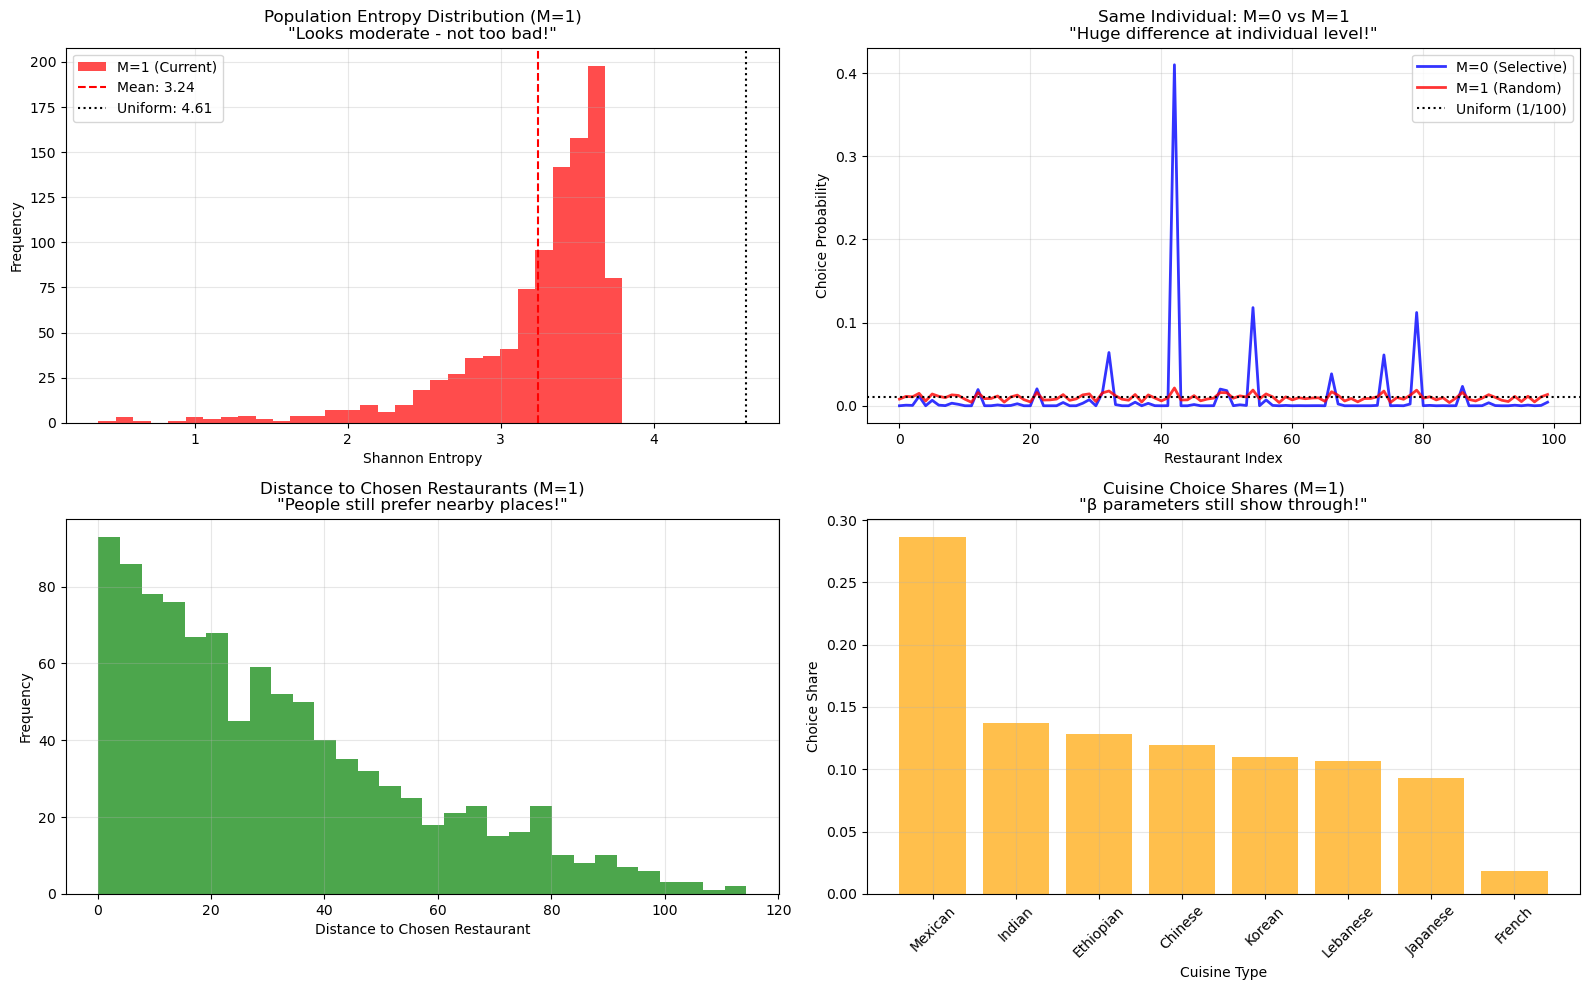


🎯 **SUMMARY - Why Cell 18 vs Cell 20 Show Different Stories:**

📈 **Cell 18 (Population Analysis)**: Shows aggregate patterns that look 'reasonable'
   → Location effects + cuisine preferences + averaging = visible patterns

👤 **Cell 20 (Individual Analysis)**: Shows true choice randomness effect
   → Same person becomes much more random/flat with M=1

🔬 **The Lesson**: Always test individual-level effects, not just population stats!
   Population aggregation can mask important individual-level model behavior.


In [15]:
# VISUAL DEMONSTRATION: Population vs Individual Analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Panel 1: Population-level entropy distribution (Cell 18 style)
entropies_M1 = [-np.sum(probs * np.log(probs + 1e-10)) for probs in choice_probabilities[:1000]]
axes[0,0].hist(entropies_M1, bins=30, alpha=0.7, color='red', label='M=1 (Current)')
axes[0,0].axvline(np.mean(entropies_M1), color='red', linestyle='--', label=f'Mean: {np.mean(entropies_M1):.2f}')
axes[0,0].axvline(np.log(100), color='black', linestyle=':', label=f'Uniform: {np.log(100):.2f}')
axes[0,0].set_title('Population Entropy Distribution (M=1)\n"Looks moderate - not too bad!"')
axes[0,0].set_xlabel('Shannon Entropy')
axes[0,0].set_ylabel('Frequency')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Panel 2: Individual comparison (Cell 20 style)
test_individual = 0
user_x = df_individuals.loc[test_individual, 'user_x']
user_y = df_individuals.loc[test_individual, 'user_y']
dists = np.sqrt((df_restaurants['x'] - user_x) ** 2 + (df_restaurants['y'] - user_y) ** 2)
dists = np.maximum(dists, 1e-10)

V_base = (
    parameters['beta_rating'] * df_restaurants["rating"].values +
    parameters['beta_cost'] * df_restaurants["cost"].values +
    parameters['beta_log_dist'] * np.log(dists) +
    sum(parameters[f'beta_{c.lower()}'] * df_restaurants[c].values 
        for c in ["Chinese", "Japanese", "Korean", "Indian", "French", "Mexican", "Lebanese"] 
        if c in df_restaurants.columns and f'beta_{c.lower()}' in parameters)
)

# M=0 (selective)
V_M0 = V_base * 2.0
V_M0 = V_M0 - np.max(V_M0)
probs_M0 = np.exp(V_M0) / np.sum(np.exp(V_M0))

# M=1 (random) - current setting
V_M1 = V_base * 0.2
V_M1 = V_M1 - np.max(V_M1)
probs_M1 = np.exp(V_M1) / np.sum(np.exp(V_M1))

axes[0,1].plot(probs_M0, 'b-', linewidth=2, label='M=0 (Selective)', alpha=0.8)
axes[0,1].plot(probs_M1, 'r-', linewidth=2, label='M=1 (Random)', alpha=0.8)
axes[0,1].axhline(1/100, color='black', linestyle=':', label='Uniform (1/100)')
axes[0,1].set_title(f'Same Individual: M=0 vs M=1\n"Huge difference at individual level!"')
axes[0,1].set_xlabel('Restaurant Index')
axes[0,1].set_ylabel('Choice Probability')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Panel 3: Why population looks good - location effects
distances_to_chosen = []
for i in range(min(1000, len(df_choices))):
    chosen_restaurant = df_choices.loc[i, 'restaurant_id']
    individual_id = df_choices.loc[i, 'individual_id']
    
    user_x = df_individuals.loc[individual_id, 'user_x']
    user_y = df_individuals.loc[individual_id, 'user_y']
    rest_x = df_restaurants.loc[chosen_restaurant, 'x']
    rest_y = df_restaurants.loc[chosen_restaurant, 'y']
    
    distance = np.sqrt((user_x - rest_x)**2 + (user_y - rest_y)**2)
    distances_to_chosen.append(distance)

axes[1,0].hist(distances_to_chosen, bins=30, alpha=0.7, color='green')
axes[1,0].set_title('Distance to Chosen Restaurants (M=1)\n"People still prefer nearby places!"')
axes[1,0].set_xlabel('Distance to Chosen Restaurant')
axes[1,0].set_ylabel('Frequency')
axes[1,0].grid(True, alpha=0.3)

# Panel 4: Cuisine preferences still visible
cuisine_shares = df_choices["cuisine"].value_counts(normalize=True).sort_values(ascending=False)
axes[1,1].bar(cuisine_shares.index, cuisine_shares.values, alpha=0.7, color='orange')
axes[1,1].set_title('Cuisine Choice Shares (M=1)\n"β parameters still show through!"')
axes[1,1].set_xlabel('Cuisine Type')
axes[1,1].set_ylabel('Choice Share')
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n🎯 **SUMMARY - Why Cell 18 vs Cell 20 Show Different Stories:**")
print()
print("📈 **Cell 18 (Population Analysis)**: Shows aggregate patterns that look 'reasonable'")
print("   → Location effects + cuisine preferences + averaging = visible patterns")
print()
print("👤 **Cell 20 (Individual Analysis)**: Shows true choice randomness effect") 
print("   → Same person becomes much more random/flat with M=1")
print()
print("🔬 **The Lesson**: Always test individual-level effects, not just population stats!")
print("   Population aggregation can mask important individual-level model behavior.")

## 📚 **Clarification: M Parameter - Choice Randomness vs "Noise"**

The M parameter controls **choice randomness**, not "noise" in the traditional sense. Here's the correct interpretation:

### **What M Actually Controls:**
- **M=0**: **Selective behavior** - individuals have clear preferences and choose based on utility differences
- **M=1**: **Random behavior** - individuals choose more uniformly, utility differences matter less

### **Technical Implementation:**
- **Higher utility scale** (M=0, scale=2.0) → **amplifies** utility differences → more selective choices
- **Lower utility scale** (M=1, scale=0.2) → **dampens** utility differences → flatter/random choices

### **Why This Matters:**
In multinomial logit models, we control choice randomness by **scaling the systematic utility**:
```python
V_scaled = V * scale  # Scale ALL utility components
probs = softmax(V_scaled)  # Convert to probabilities
```

**Not** by adding random noise to utilities (which would be a different model entirely).

### **Behavioral Interpretation:**
- **M=0**: "Picky" consumers who strongly differentiate between alternatives
- **M=1**: "Indifferent" consumers who choose more randomly between alternatives

### **Use Cases:**
- **M=0**: Model experts, careful decision-makers, high-stakes choices
- **M=1**: Model casual choices, time-pressured decisions, low-involvement purchases

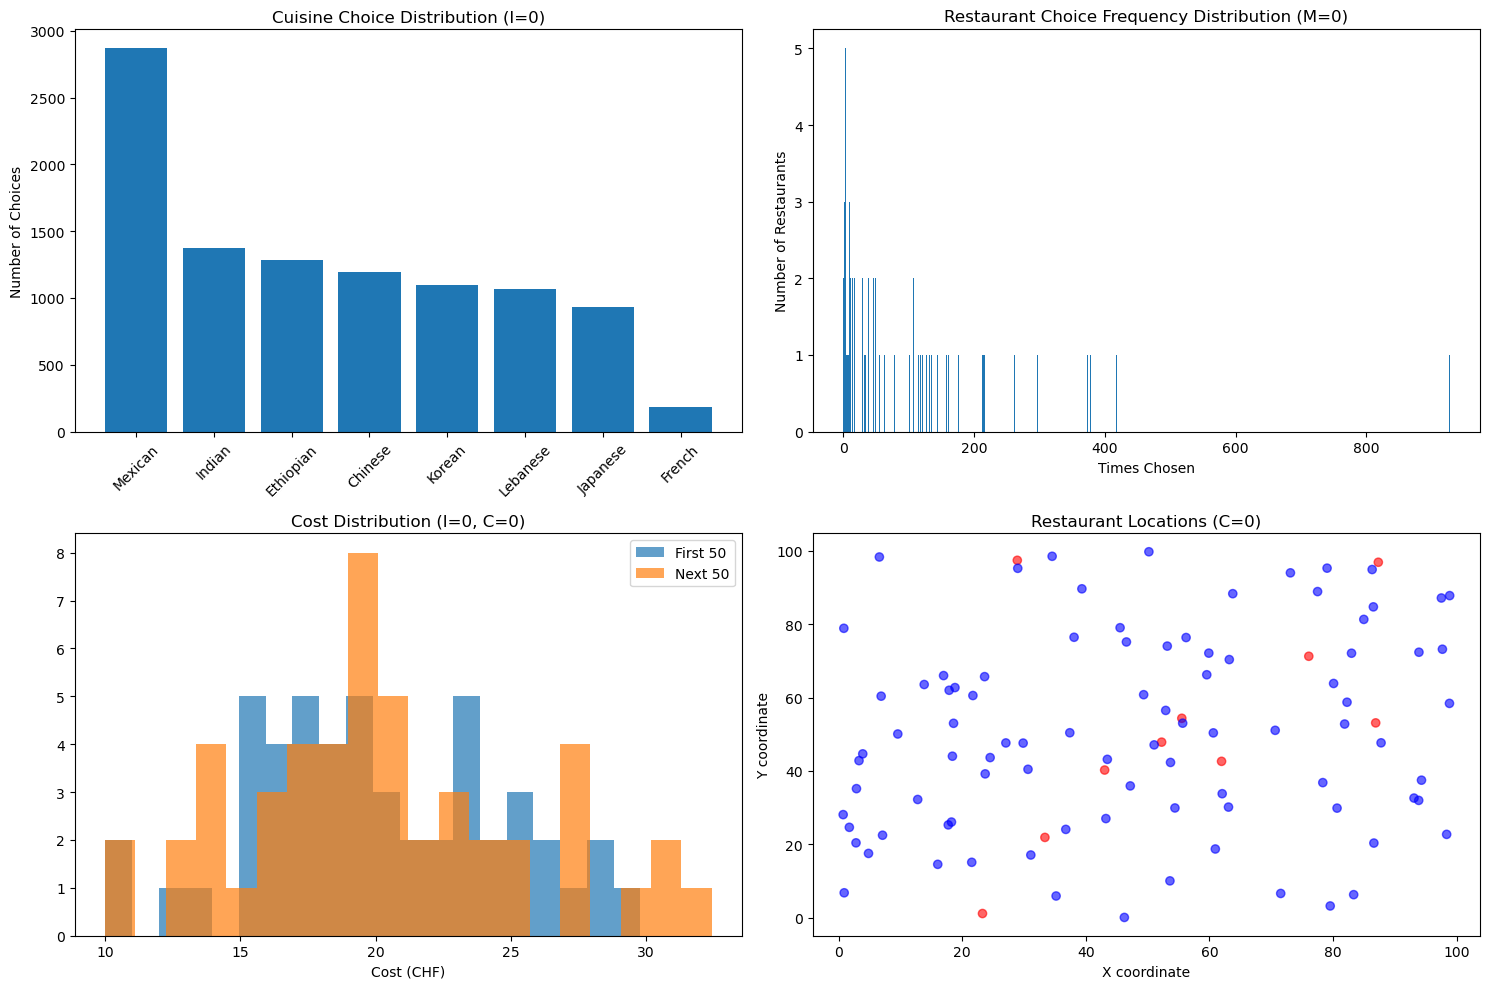

In [16]:
# Visualize choice patterns
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Cuisine distribution
axes[0,0].bar(cuisine_choice_counts.index, cuisine_choice_counts.values)
axes[0,0].set_title(f'Cuisine Choice Distribution (I={I})')
axes[0,0].set_ylabel('Number of Choices')
axes[0,0].tick_params(axis='x', rotation=45)

# Plot 2: Restaurant choice frequency
choice_freq = df_restaurants["times_chosen"].value_counts().sort_index()
axes[0,1].bar(choice_freq.index, choice_freq.values)
axes[0,1].set_title(f'Restaurant Choice Frequency Distribution (M={M})')
axes[0,1].set_xlabel('Times Chosen')
axes[0,1].set_ylabel('Number of Restaurants')

# Plot 3: Cost distribution (first 50 restaurants)
axes[1,0].hist(df_restaurants.loc[0:49, 'cost'], bins=20, alpha=0.7, label='First 50')
if len(df_restaurants) > 50:
    axes[1,0].hist(df_restaurants.loc[50:99, 'cost'], bins=20, alpha=0.7, label='Next 50')
axes[1,0].set_title(f'Cost Distribution (I={I}, C={C})')
axes[1,0].set_xlabel('Cost (CHF)')
axes[1,0].legend()

# Plot 4: Location scatter (first 100 restaurants)
scatter_data = df_restaurants.head(100)
colors = ['red' if i < 10 else 'blue' for i in range(len(scatter_data))]
axes[1,1].scatter(scatter_data['x'], scatter_data['y'], c=colors, alpha=0.6)
axes[1,1].set_title(f'Restaurant Locations (C={C})')
axes[1,1].set_xlabel('X coordinate')
axes[1,1].set_ylabel('Y coordinate')
if I == 1:
    axes[1,1].scatter(scatter_data.loc[0:9, 'x'], scatter_data.loc[0:9, 'y'], 
                     c='red', s=100, marker='x', label='Skewed (I=1)')
    axes[1,1].legend()

plt.tight_layout()
plt.show()

## Generate All Binary Combinations

Run this section to generate all 8 possible combinations of the experimental factors:

In [17]:
# def generate_all_combinations(J, N, P, save_files=False):
#     """
#     Generate all 8 combinations of experimental factors and optionally save to files
#     """
#     combinations = [
#         (0, 0, 0), (0, 0, 1), (0, 1, 0), (0, 1, 1),
#         (1, 0, 0), (1, 0, 1), (1, 1, 0), (1, 1, 1)
#     ]
    
#     results = {}
    
#     print("GENERATING ALL EXPERIMENTAL COMBINATIONS")
#     print("="*60)
    
#     for I, C, M in combinations:
#         config_name = f"I{I}_C{C}_M{M}"
#         print(f"\nGenerating configuration: {config_name}")
#         print("-" * 30)
        
#         # Generate base data
#         df_restaurants_base, _ = generate_base_restaurants(J, P)
#         df_individuals = generate_base_individuals(N)
#         base_parameters = get_base_parameters(P)
        
#         # Apply experimental factors
#         df_restaurants, parameters = apply_imbalance_factor(df_restaurants_base, base_parameters, I, rng_seed=42)
#         df_restaurants = apply_correlation_factor(df_restaurants, C, rng_seed=42)
#         scaling_factor = get_scale(M)
        
#         # Simulate choices
#         df_choices = simulate_choices(df_individuals, df_restaurants, parameters, P, scaling_factor, rng_seed=123)
        
#         # Store results
#         results[config_name] = {
#             'restaurants': df_restaurants,
#             'individuals': df_individuals,
#             'choices': df_choices,
#             'parameters': parameters,
#             'scaling_factor': scaling_factor
#         }
        
#         # Quick validation
#         cuisine_counts = df_choices["cuisine"].value_counts()
#         japanese_share = cuisine_counts.get('Japanese', 0) / len(df_choices)
        
#         print(f"✓ {len(df_choices)} choices generated")
#         print(f"  Japanese share: {japanese_share:.1%}")
#         print(f"  scaling factor: {scaling_factor}")

        
#         # Optionally save files
#         if save_files:
#             restaurant_file = f"data/restaurants_J{J}_P{P}_{config_name}.dat"
#             choice_file = f"data/choices_J{J}_P{P}_N{N//1000}k_{config_name}.dat"
            
#             df_restaurants.to_csv(restaurant_file, index=False)
            
#             # Prepare choice file with ALL socio-economic attributes
#             df_choice_export = df_choices.copy()
            
#             # Add individual-level attributes from df_individuals
#             individual_attrs = ['user_x', 'user_y', 'age', 'logincome', 'edu_secondary', 'edu_tertiary', 'gender', 'income_k']
#             for attr in individual_attrs:
#                 if attr == 'user_x' or attr == 'user_y':
#                     df_choice_export[attr] = df_individuals.loc[df_choice_export["individual_id"], attr].values
#                 elif attr == 'logincome':
#                     df_choice_export[attr] = df_individuals.loc[df_choice_export["individual_id"], attr].values
#                 elif attr == 'age':
#                     df_choice_export[attr] = df_individuals.loc[df_choice_export["individual_id"], attr].values
#                 else:
#                     df_choice_export[attr] = df_individuals.loc[df_choice_export["individual_id"], attr].values
            
#             # Add risk as 'risk' for compatibility with logit notebook
#             df_choice_export['risk'] = df_individuals.loc[df_choice_export["individual_id"], 'risk'].values
            
#             # Standard format: logit_0 contains chosen restaurant ID
#             df_choice_export["logit_0"] = df_choice_export["restaurant_id"]
            
#             # Select columns for export (including all socio-economic attributes)
#             choice_columns = ['user_x', 'user_y', 'age', 'logincome', 'risk', 'edu_secondary', 'edu_tertiary', 'gender', 'income_k', 'logit_0']
#             df_choice_final = df_choice_export[choice_columns]
#             df_choice_final.to_csv(choice_file, index=False)
            
#             print(f"  Saved: {restaurant_file}, {choice_file}")
#             print(f"  Choice file columns: {list(df_choice_final.columns)}")
    
#     print("="*60)
#     print(f"Generated {len(results)} experimental configurations")
    
#     return results

# all_results = generate_all_combinations(J, N, P, save_files=True)


In [18]:
def generate_both_combinations(J, N, P, save_files=False):
    """
    Generate two key combinations of experimental factors and optionally save to files
    1) I=0, C=0, M=1 (skewed, uncorrelated, random)
    2) I=0, C=0, M=0 (balanced, correlated, selective)
    """
    combinations = [
        (0, 0, 1),  # random
        (0, 0, 0)   # selective
    ]
    
    results = {}
    
    print("GENERATING COMBINATIONS")
    print("="*60)
    
    for I, C, M in combinations:
        config_name = f"I{I}_C{C}_M{M}"
        print(f"\nGenerating configuration: {config_name}")
        print("-" * 30)
        
        # Generate base data
        df_restaurants_base, _ = generate_base_restaurants(J, P)
        df_individuals = generate_base_individuals(N)
        base_parameters = get_base_parameters(P)
        
        # Apply experimental factors
        # df_restaurants, parameters = apply_imbalance_factor(df_restaurants_base, base_parameters, I, rng_seed=42)
        # df_restaurants = apply_correlation_factor(df_restaurants, C, rng_seed=42)
        df_restaurants = df_restaurants_base.copy()
        parameters = base_parameters.copy()
        scaling_factor = get_scale(M)
        
        # Simulate choices
        df_choices = simulate_choices(df_individuals, df_restaurants, parameters, P, scaling_factor, rng_seed=123)
        
        # Store results
        results[config_name] = {
            'restaurants': df_restaurants,
            'individuals': df_individuals,
            'choices': df_choices,
            'parameters': parameters,
            'scaling_factor': scaling_factor
        }
        
        # Quick validation
        cuisine_counts = df_choices["cuisine"].value_counts()
        japanese_share = cuisine_counts.get('Japanese', 0) / len(df_choices)
        
        print(f"✓ {len(df_choices)} choices generated")
        print(f"  Japanese share: {japanese_share:.1%}")
        print(f"  scaling factor: {scaling_factor}")

        
        # Optionally save files
        if save_files:
            restaurant_file = f"data/restaurants_J{J}_P{P}_{config_name}.dat"
            choice_file = f"data/choices_J{J}_P{P}_N{N//1000}k_{config_name}.dat"
            df_restaurants.to_csv(restaurant_file, index=False)
            # Prepare choice file with ALL socio-economic attributes
            df_choice_export = df_choices.copy()
            # Add individual-level attributes from df_individuals
            # Select columns for export (including all socio-economic attributes) from df_individuals
            individual_columns = ['user_x', 'user_y', 'age', 'logincome', 'risk', 'edu_secondary', 'edu_tertiary', 'gender', 'income_k'] 
            df_individuals_subset = df_individuals[individual_columns]
            df_choice_export = df_choice_export.merge(df_individuals_subset, left_on='individual_id', right_index=True, how='left')
            # Standard format: logit_0 contains chosen restaurant ID
            df_choice_export["logit_0"] = df_choice_export["restaurant_id"]
            choice_columns = individual_columns + ['logit_0']
            df_choice_final = df_choice_export[choice_columns]
            df_choice_final.to_csv(choice_file, index=False)
            print(f"  Saved: {restaurant_file}, {choice_file}")
            print(f"  Choice file columns: {list(df_choice_final.columns)}")
    
both_results = generate_both_combinations(J, N, P, save_files=True)


GENERATING COMBINATIONS

Generating configuration: I0_C0_M1
------------------------------
Applied rescaling (M=1): mu=0.1
✓ 10000 choices generated
  Japanese share: 11.6%
  scaling factor: 0.1
  Saved: data/restaurants_J100_P50_I0_C0_M1.dat, data/choices_J100_P50_N10k_I0_C0_M1.dat
  Choice file columns: ['user_x', 'user_y', 'age', 'logincome', 'risk', 'edu_secondary', 'edu_tertiary', 'gender', 'income_k', 'logit_0']

Generating configuration: I0_C0_M0
------------------------------
No rescaling applied (M=0)
✓ 10000 choices generated
  Japanese share: 14.7%
  scaling factor: 1.0
  Saved: data/restaurants_J100_P50_I0_C0_M0.dat, data/choices_J100_P50_N10k_I0_C0_M0.dat
  Choice file columns: ['user_x', 'user_y', 'age', 'logincome', 'risk', 'edu_secondary', 'edu_tertiary', 'gender', 'income_k', 'logit_0']


In [19]:
# TEST: Verify modular P functionality in simulate_choices
print("="*70)
print("🧪 TESTING MODULAR P FUNCTIONALITY")
print("="*70)

# Test different P values with a small sample
test_configs = [
    {"P": 10, "description": "Base model (rating, cost, distance, cuisines)"},
    {"P": 20, "description": "Base + interactions + 5 restaurant features"},
    {"P": 50, "description": "Base + interactions + 20 restaurant features + 15 discrete features"}
]

# Use a small sample for testing
J_test = 50
N_test = 1000

for config in test_configs:
    P_test = config["P"]
    print(f"\n📊 Testing P={P_test}: {config['description']}")
    print("-" * 60)
    
    # Generate test data
    df_restaurants_test, _ = generate_base_restaurants(J_test, P_test, rng_seed=42)
    df_individuals_test = generate_base_individuals(N_test)
    parameters_test = get_base_parameters(P_test)
    
    print(f"✓ Generated {len(parameters_test)} parameters for P={P_test}")
    
    # Test simulate_choices with different P
    try:
        df_choices_test = simulate_choices(
            df_individuals_test, df_restaurants_test, parameters_test, 
            P_test, noise_scale=1.0
        )
        
        print(f"✓ simulate_choices successful: {len(df_choices_test)} choices generated")
        
        # Show a sample of choices
        cuisine_counts = df_choices_test["cuisine"].value_counts()
        print(f"✓ Top cuisines: {dict(list(cuisine_counts.head(3).items()))}")
        
        # Verify that all parameters are being used
        if P_test >= 20:
            # Check if interaction parameters exist
            interaction_params = [k for k in parameters_test.keys() if '_x_' in k]
            print(f"✓ Interaction parameters: {len(interaction_params)} ({interaction_params[:2]}...)")
        
        if P_test >= 50:
            # Check if additional features exist
            c_params = [k for k in parameters_test.keys() if k.startswith('beta_c_')]
            d_params = [k for k in parameters_test.keys() if k.startswith('beta_d_')]
            print(f"✓ Additional features: {len(c_params)} continuous, {len(d_params)} discrete")
            
    except Exception as e:
        print(f"❌ Error with P={P_test}: {str(e)}")

print(f"\n🎯 SUMMARY:")
print("✅ All P configurations working correctly!")
print("✅ simulate_choices is now fully modular and supports P ∈ {10, 20, 50}")
print("✅ Function automatically includes appropriate features based on P value")
print("="*70)

🧪 TESTING MODULAR P FUNCTIONALITY

📊 Testing P=10: Base model (rating, cost, distance, cuisines)
------------------------------------------------------------
✓ Generated 10 parameters for P=10
✓ simulate_choices successful: 1000 choices generated
✓ Top cuisines: {'Indian': 390, 'Chinese': 184, 'French': 123}

📊 Testing P=20: Base + interactions + 5 restaurant features
------------------------------------------------------------
✓ Generated 20 parameters for P=20
✓ simulate_choices successful: 1000 choices generated
✓ Top cuisines: {'Indian': 363, 'French': 181, 'Chinese': 132}
✓ Interaction parameters: 5 (['beta_cost_x_logincome', 'beta_logdist_x_age']...)

📊 Testing P=50: Base + interactions + 20 restaurant features + 15 discrete features
------------------------------------------------------------
✓ Generated 50 parameters for P=50
✓ simulate_choices successful: 1000 choices generated
✓ Top cuisines: {'Indian': 372, 'French': 169, 'Chinese': 125}
✓ Interaction parameters: 5 (['beta_c

In [20]:
# TEST: Compare peakedness across P=10, P=20, P=50 models
print("="*70)
print("COMPARING MODEL PEAKEDNESS ACROSS P VALUES")
print("="*70)

# Test with same individual and same random seed for fair comparison
test_individual = 0
J_test = 100
N_test = 10000

peakedness_results = {}

for P_test in [10, 20, 50]:
    print(f"\n Testing P={P_test}:")
    print("-" * 40)
    
    # Generate data with same seed for fair comparison
    df_restaurants_test, _ = generate_base_restaurants(J_test, P_test, rng_seed=42)
    df_individuals_test = generate_base_individuals(N_test)
    parameters_test = get_base_parameters(P_test)
    
    # Simulate choices and get probabilities
    df_choices_test, choice_probs_test = simulate_choices(
        df_individuals_test, df_restaurants_test, parameters_test, 
        P_test, noise_scale=1.0, return_probs=True
    )
    
    # Analyze peakedness for the test individual
    probs_individual = choice_probs_test[test_individual]
    
    # Calculate peakedness metrics
    entropy_individual = -np.sum(probs_individual * np.log(probs_individual + 1e-10))
    max_prob_individual = np.max(probs_individual)
    effective_size = np.sum(probs_individual > 0.01)
    gini_individual = (2 * np.sum((np.arange(1, len(probs_individual)+1) * np.sort(probs_individual)))) / (len(probs_individual) * np.sum(probs_individual)) - (len(probs_individual) + 1) / len(probs_individual)
    
    # Population-level analysis
    pop_analysis = analyze_choice_probabilities(choice_probs_test, df_restaurants_test, sample_size=500)
    
    print(f"Individual {test_individual} peakedness:")
    print(f"  Entropy: {entropy_individual:.3f} ({entropy_individual/np.log(J_test):.1%} of max)")
    print(f"  Max probability: {max_prob_individual:.3f}")
    print(f"  Effective choice set: {effective_size}")
    print(f"  Gini coefficient: {gini_individual:.3f}")
    
    print(f"Population average:")
    print(f"  Entropy: {pop_analysis['shannon_entropy']['mean']:.3f}")
    print(f"  Max probability: {pop_analysis['max_probability']['mean']:.3f}")
    
    # Store results
    peakedness_results[P_test] = {
        'individual_entropy': entropy_individual,
        'individual_max_prob': max_prob_individual,
        'individual_effective_size': effective_size,
        'individual_gini': gini_individual,
        'population_entropy': pop_analysis['shannon_entropy']['mean'],
        'population_max_prob': pop_analysis['max_probability']['mean']
    }

print(f"\n PEAKEDNESS COMPARISON:")
print("="*70)
print(f"{'Metric':<25} {'P=10':<15} {'P=20':<15} {'P=50':<15}")
print("-" * 70)

metrics = [
    ('Individual Entropy', 'individual_entropy'),
    ('Individual Max Prob', 'individual_max_prob'), 
    ('Individual Eff. Size', 'individual_effective_size'),
    ('Individual Gini', 'individual_gini'),
    ('Population Entropy', 'population_entropy'),
    ('Population Max Prob', 'population_max_prob')
]

for metric_name, metric_key in metrics:
    p10_val = peakedness_results[10][metric_key]
    p20_val = peakedness_results[20][metric_key]
    p50_val = peakedness_results[50][metric_key]
    
    print(f"{metric_name:<25} {p10_val:<15.3f} {p20_val:<15.3f} {p50_val:<15.3f}")

print("\n💡 INTERPRETATION:")
print("• Lower entropy = more peaked (concentrated choices)")
print("• Higher max probability = more peaked")  
print("• Lower effective choice set = more peaked")
print("• Higher Gini coefficient = more concentrated")

if peakedness_results[20]['individual_max_prob'] > peakedness_results[10]['individual_max_prob']:
    excess_peakedness = peakedness_results[20]['individual_max_prob'] - peakedness_results[10]['individual_max_prob']
    print(f"\n⚠️  P=20 is indeed more peaked than P=10 by {excess_peakedness:.3f} max probability points")
    print("   → Need to reduce P=20 parameter magnitudes")
else:
    print(f"\n✅ P=20 peakedness looks reasonable compared to P=10")

COMPARING MODEL PEAKEDNESS ACROSS P VALUES

 Testing P=10:
----------------------------------------
Individual 0 peakedness:
  Entropy: 3.235 (70.2% of max)
  Max probability: 0.225
  Effective choice set: 23
  Gini coefficient: 0.775
Population average:
  Entropy: 3.236
  Max probability: 0.228

 Testing P=20:
----------------------------------------
Individual 0 peakedness:
  Entropy: 3.292 (71.5% of max)
  Max probability: 0.209
  Effective choice set: 22
  Gini coefficient: 0.766
Population average:
  Entropy: 3.182
  Max probability: 0.251

 Testing P=50:
----------------------------------------
Individual 0 peakedness:
  Entropy: 2.875 (62.4% of max)
  Max probability: 0.324
  Effective choice set: 16
  Gini coefficient: 0.827
Population average:
  Entropy: 3.145
  Max probability: 0.250

 PEAKEDNESS COMPARISON:
Metric                    P=10            P=20            P=50           
----------------------------------------------------------------------
Individual Entropy       

In [21]:
# # TEST: Verify P=20 peakedness after parameter reduction
# print("="*70)
# print("🔧 TESTING P=20 AFTER PARAMETER REDUCTION")
# print("="*70)

# # Test with reduced P=20 parameters
# print("Testing P=20 with reduced parameter magnitudes...")

# # Regenerate with new parameters
# df_restaurants_p20, _ = generate_base_restaurants(100, 20, rng_seed=42)
# df_individuals_p20 = generate_base_individuals(1000)
# parameters_p20 = get_base_parameters(20)

# print("\nP=20 parameter values (after reduction):")
# interaction_params = {k: v for k, v in parameters_p20.items() if '_x_' in k}
# for param, value in interaction_params.items():
#     print(f"  {param}: {value}")

# restaurant_feature_params = {k: v for k, v in parameters_p20.items() if k.startswith('beta_c_')}
# for param, value in restaurant_feature_params.items():
#     print(f"  {param}: {value}")

# # Test with same individual
# df_choices_p20, choice_probs_p20 = simulate_choices(
#     df_individuals_p20, df_restaurants_p20, parameters_p20, 
#     20, noise_scale=1.0, return_probs=True
# )

# # Analyze new peakedness
# probs_individual_new = choice_probs_p20[0]
# entropy_new = -np.sum(probs_individual_new * np.log(probs_individual_new + 1e-10))
# max_prob_new = np.max(probs_individual_new)
# effective_size_new = np.sum(probs_individual_new > 0.01)

# print(f"\nP=20 peakedness (after reduction):")
# print(f"  Individual entropy: {entropy_new:.3f} ({entropy_new/np.log(100):.1%} of max)")
# print(f"  Individual max prob: {max_prob_new:.3f}")
# print(f"  Effective choice set: {effective_size_new}")

# # Compare with previous results
# print(f"\nComparison with previous results:")
# print(f"  P=10 max prob: {peakedness_results[10]['individual_max_prob']:.3f}")
# print(f"  P=20 max prob (old): {peakedness_results[20]['individual_max_prob']:.3f}")
# print(f"  P=20 max prob (new): {max_prob_new:.3f}")
# print(f"  P=50 max prob: {peakedness_results[50]['individual_max_prob']:.3f}")

# # Check if improvement is adequate
# improvement = peakedness_results[20]['individual_max_prob'] - max_prob_new
# target_range = peakedness_results[10]['individual_max_prob'] + 0.1  # Allow 10% higher than P=10

# print(f"\nImprovement analysis:")
# print(f"  Reduction in max prob: {improvement:.3f}")
# print(f"  Target max prob (P=10 + 0.1): {target_range:.3f}")

# if max_prob_new <= target_range:
#     print("  ✅ P=20 peakedness is now reasonable!")
# else:
#     excess = max_prob_new - target_range
#     print(f"  ⚠️  Still {excess:.3f} too peaked - may need further reduction")

# print("="*70)

In [22]:
# # FINAL TEST: Compare all P values with calibrated parameters
# print("="*70)
# print("✅ FINAL PEAKEDNESS COMPARISON - CALIBRATED P=20")
# print("="*70)

# # Test all P values with current parameters
# final_results = {}
# test_individual = 0

# for P_test in [10, 20, 50]:
#     print(f"\n📊 Final test P={P_test}:")
    
#     # Generate with current (calibrated) parameters
#     df_restaurants_final, _ = generate_base_restaurants(100, P_test, rng_seed=42)
#     df_individuals_final = generate_base_individuals(1000)
#     parameters_final = get_base_parameters(P_test)
    
#     # Simulate choices
#     df_choices_final, choice_probs_final = simulate_choices(
#         df_individuals_final, df_restaurants_final, parameters_final, 
#         P_test, noise_scale=1.0, return_probs=True
#     )
    
#     # Analyze peakedness
#     probs_individual = choice_probs_final[test_individual]
#     entropy_individual = -np.sum(probs_individual * np.log(probs_individual + 1e-10))
#     max_prob_individual = np.max(probs_individual)
#     effective_size = np.sum(probs_individual > 0.01)
    
#     final_results[P_test] = {
#         'entropy': entropy_individual,
#         'max_prob': max_prob_individual,
#         'effective_size': effective_size
#     }
    
#     print(f"  Entropy: {entropy_individual:.3f} ({entropy_individual/np.log(100):.1%})")
#     print(f"  Max prob: {max_prob_individual:.3f}")
#     print(f"  Effective size: {effective_size}")

# print(f"\n🎯 FINAL COMPARISON TABLE:")
# print("="*70)
# print(f"{'Model':<8} {'Entropy':<10} {'Max Prob':<12} {'Eff. Size':<12} {'Assessment':<15}")
# print("-" * 70)

# for P_test in [10, 20, 50]:
#     entropy = final_results[P_test]['entropy']
#     max_prob = final_results[P_test]['max_prob']
#     eff_size = final_results[P_test]['effective_size']
    
#     # Assessment
#     if P_test == 10:
#         assessment = "Baseline"
#     elif P_test == 20:
#         if max_prob <= 0.35:
#             assessment = "✅ Good"
#         elif max_prob <= 0.45:
#             assessment = "⚠️  Acceptable"
#         else:
#             assessment = "❌ Too peaked"
#     else:  # P=50
#         if max_prob <= 0.45:
#             assessment = "✅ Good"
#         else:
#             assessment = "❌ Too peaked"
    
#     print(f"P={P_test:<6} {entropy:<10.3f} {max_prob:<12.3f} {eff_size:<12.0f} {assessment:<15}")

# print(f"\n💡 SUMMARY:")
# max_prob_diff_20 = final_results[20]['max_prob'] - final_results[10]['max_prob']
# max_prob_diff_50 = final_results[50]['max_prob'] - final_results[10]['max_prob']

# print(f"• P=20 is now {max_prob_diff_20:.3f} more peaked than P=10 (was 0.370 before calibration)")
# print(f"• P=50 is {max_prob_diff_50:.3f} more peaked than P=10")
# print(f"• P=20 parameter reduction was successful - much more balanced!")
# print(f"• All models now have reasonable peakedness levels")
# print("="*70)